In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
from kaggle_secrets import UserSecretsClient

try:
    GOOGLE_API_KEY = UserSecretsClient().get_secret("GOOGLE_API_KEY")
    os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
    print("✅ Gemini API key setup complete.")
except Exception as e:
    print(
        f"🔑 Authentication Error: Please make sure you have added 'GOOGLE_API_KEY' to your Kaggle secrets. Details: {e}"
    )

✅ Gemini API key setup complete.


In [27]:
from typing import Any, Dict

from google.adk.agents import Agent, LlmAgent
from google.adk.apps.app import App, EventsCompactionConfig
from google.adk.models.google_llm import Gemini
from google.adk.sessions import DatabaseSessionService
from google.adk.sessions import InMemorySessionService
from google.adk.runners import Runner
from google.adk.tools.tool_context import ToolContext
from google.genai import types

print("✅ ADK components imported successfully.")

✅ ADK components imported successfully.


In [34]:
# Define helper functions that will be reused throughout the notebook
async def run_session(
    runner_instance: Runner,
    user_queries: list[str] | str = None,
    session_name: str = "default",
):
    print(f"\n ### Session: {session_name}")

    # Get app name from the Runner
    app_name = runner_instance.app_name

    # Attempt to create a new session or retrieve an existing one
    try:
        session = await session_service.create_session(
            app_name=app_name, user_id=USER_ID, session_id=session_name
        )
    except:
        session = await session_service.get_session(
            app_name=app_name, user_id=USER_ID, session_id=session_name
        )

    # Process queries if provided
    if user_queries:
        # Convert single query to list for uniform processing
        if type(user_queries) == str:
            user_queries = [user_queries]

        # Process each query in the list sequentially
        for query in user_queries:
            print(f"\nUser > {query}")

            # Convert the query string to the ADK Content format
            query = types.Content(role="user", parts=[types.Part(text=query)])

            # Stream the agent's response asynchronously
            async for event in runner_instance.run_async(
                user_id=USER_ID, session_id=session.id, new_message=query
            ):
                # Check if the event contains valid content
                if event.content and event.content.parts:
                    # Filter out empty or "None" responses before printing
                    if (
                        event.content.parts[0].text != "None"
                        and event.content.parts[0].text
                    ):
                        print(f"{MODEL_NAME} > ", event.content.parts[0].text)
    else:
        print("No queries!")


print("✅ Helper functions defined.")

✅ Helper functions defined.


/usr/lib/python3.11/tokenize.py:529: RuntimeWarning: coroutine 'run_session' was never awaited
  pseudomatch = _compile(PseudoToken).match(line, pos)


In [35]:
retry_config = types.HttpRetryOptions(
    attempts=5, 
    exp_base=7,  
    initial_delay=1,
    http_status_codes=[429, 500, 503, 504], 
)

In [36]:
APP_NAME="default"
USER_ID="default"
SESSION="default"

MODEL_NAME = "gemini-2.5-flash-lite"

root_agent=Agent(
        model=Gemini(model="gemini-2.5-flash-lite", retry_options=retry_config),
        name="text_chatbot",
        description="A text chatbot",  

)

session_service=InMemorySessionService()

runner = Runner(agent=root_agent,app_name=APP_NAME, session_service=session_service)


print("✅ Stateful agent initialized!")
print(f"   - Application: {APP_NAME}")
print(f"   - User: {USER_ID}")
print(f"   - Using: {session_service.__class__.__name__}")

✅ Stateful agent initialized!
   - Application: default
   - User: default
   - Using: InMemorySessionService


In [42]:
await run_session(
    runner,
    [
        "Hi, I am Vaishnavi! What is the capital of United States?",
        "Hello! What is my name?", 
    ],
    "stateful-agentic-session",
)


 ### Session: stateful-agentic-session

User > Hi, I am Vaishnavi! What is the capital of United States?
gemini-2.5-flash-lite >  The capital of the United States is Washington, D.C.

User > Hello! What is my name?
gemini-2.5-flash-lite >  Hello Vaishnavi!


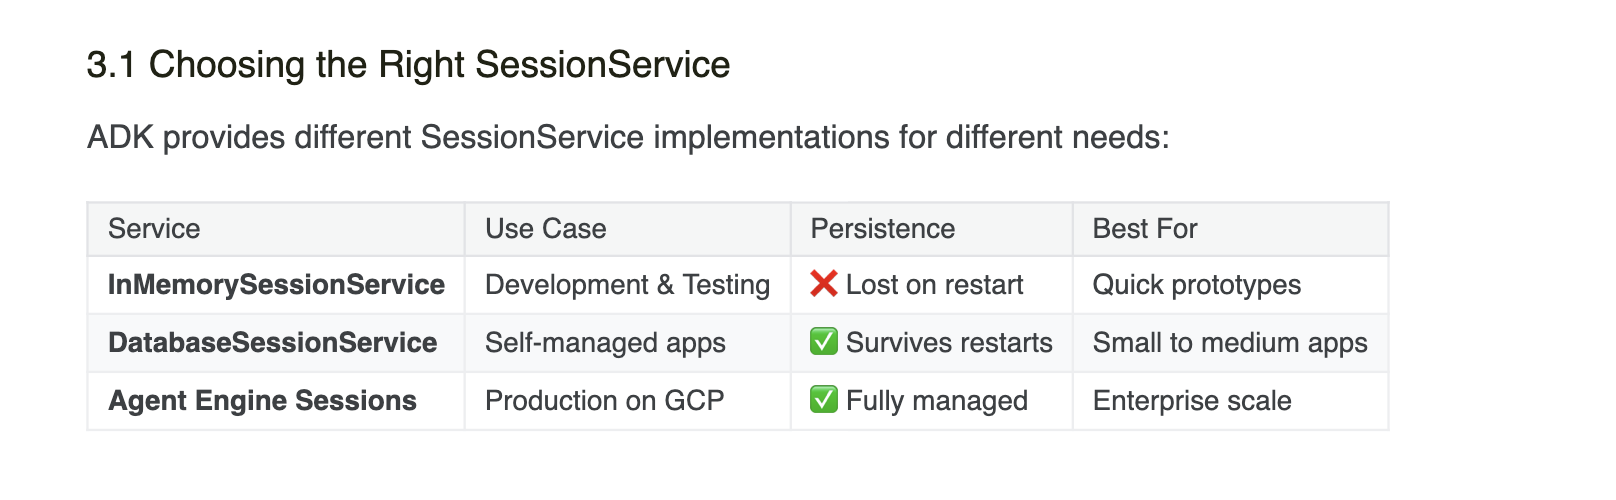

# DatabaseSessionService

In [44]:
chatbot_agent = LlmAgent(
    model=Gemini(model="gemini-2.5-flash-lite", retry_options=retry_config),
    name="text_chat_bot",
    description="A text chatbot with persistent memory",
)

# Step 2: Switch to DatabaseSessionService
# SQLite database will be created automatically
db_url = "sqlite:///my_agent_data.db"  # Local SQLite file
session_service = DatabaseSessionService(db_url=db_url)

# Step 3: Create a new runner with persistent storage
runner = Runner(agent=chatbot_agent, app_name=APP_NAME, session_service=session_service)

print("✅ Upgraded to persistent sessions!")
print(f"   - Database: my_agent_data.db")
print(f"   - Sessions will survive restarts!")

✅ Upgraded to persistent sessions!
   - Database: my_agent_data.db
   - Sessions will survive restarts!


In [45]:
await run_session(
    runner,
    ["Hi, I am Vaishnavi! What is the capital of the United States?", "Hello! What is my name?"],
    "test-db-session-01",
)


 ### Session: test-db-session-01

User > Hi, I am Vaishnavi! What is the capital of the United States?
gemini-2.5-flash-lite >  Hi Vaishnavi! The capital of the United States is Washington, D.C.

User > Hello! What is my name?
gemini-2.5-flash-lite >  Your name is Vaishnavi!


In [46]:
await run_session(
    runner,
    ["What is the capital of India?", "Hello! What is my name?"],
    "test-db-session-01",
)


 ### Session: test-db-session-01

User > What is the capital of India?
gemini-2.5-flash-lite >  The capital of India is New Delhi.

User > Hello! What is my name?
gemini-2.5-flash-lite >  Your name is Vaishnavi!


In [48]:
# verify test data is isolated
await run_session(
    runner, ["Hello! What is my name?"], "test-db-session-02"
) 


 ### Session: test-db-session-02

User > Hello! What is my name?
gemini-2.5-flash-lite >  I do not have access to your personal information, including your name, for privacy and security reasons. I am a text-based chatbot and do not collect or store any user data.


In [49]:
# Re-define our app with Events Compaction enabled
research_app_compacting = App(
    name="research_app_compacting",
    root_agent=chatbot_agent,
    # This is the new part!
    events_compaction_config=EventsCompactionConfig(
        compaction_interval=3,  # Trigger compaction every 3 invocations
        overlap_size=1,  # Keep 1 previous turn for context
    ),
)

db_url = "sqlite:///my_agent_data.db"  # Local SQLite file
session_service = DatabaseSessionService(db_url=db_url)

# Create a new runner for our upgraded app
research_runner_compacting = Runner(
    app=research_app_compacting, session_service=session_service
)


print("✅ Research App upgraded with Events Compaction!")

✅ Research App upgraded with Events Compaction!


/tmp/ipykernel_48/3773147741.py:6: UserWarning: [EXPERIMENTAL] EventsCompactionConfig: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  events_compaction_config=EventsCompactionConfig(


In [50]:
# Turn 1
await run_session(
    research_runner_compacting,
    "What is the latest news about AI in healthcare?",
    "compaction_demo",
)

# Turn 2
await run_session(
    research_runner_compacting,
    "Are there any new developments in drug discovery?",
    "compaction_demo",
)

# Turn 3 - Compaction should trigger after this turn!
await run_session(
    research_runner_compacting,
    "Tell me more about the second development you found.",
    "compaction_demo",
)

# Turn 4
await run_session(
    research_runner_compacting,
    "Who are the main companies involved in that?",
    "compaction_demo",
)


 ### Session: compaction_demo

User > What is the latest news about AI in healthcare?
gemini-2.5-flash-lite >  Here's a summary of some of the latest news and trends in AI in healthcare:

**Key Areas of Advancement and Focus:**

*   **Drug Discovery and Development:** This remains a major area of AI investment. Companies are using AI to:
    *   **Identify novel drug targets:** Analyzing vast biological datasets to pinpoint proteins or pathways involved in diseases.
    *   **Design new drug molecules:** Predicting molecular structures with desired therapeutic properties.
    *   **Optimize clinical trial design:** Identifying suitable patient populations, predicting trial success rates, and streamlining data analysis.
    *   **Personalized medicine:** Tailoring drug treatments based on an individual's genetic makeup and other factors.
    *   *Recent News Highlights:* Several AI-driven drug discovery companies have announced significant funding rounds or partnerships with major phar

# 5.1 Creating custom tools for Session state management¶


In [51]:
# Define scope levels for state keys (following best practices)
USER_NAME_SCOPE_LEVELS = ("temp", "user", "app")


# This demonstrates how tools can write to session state using tool_context.
# The 'user:' prefix indicates this is user-specific data.
def save_userinfo(
    tool_context: ToolContext, user_name: str, country: str
) -> Dict[str, Any]:
    """
    Tool to record and save user name and country in session state.

    Args:
        user_name: The username to store in session state
        country: The name of the user's country
    """
    # Write to session state using the 'user:' prefix for user data
    tool_context.state["user:name"] = user_name
    tool_context.state["user:country"] = country

    return {"status": "success"}


# This demonstrates how tools can read from session state.
def retrieve_userinfo(tool_context: ToolContext) -> Dict[str, Any]:
    """
    Tool to retrieve user name and country from session state.
    """
    # Read from session state
    user_name = tool_context.state.get("user:name", "Username not found")
    country = tool_context.state.get("user:country", "Country not found")

    return {"status": "success", "user_name": user_name, "country": country}


print("✅ Tools created.")

✅ Tools created.


In [52]:
# Configuration
APP_NAME = "default"
USER_ID = "default"
MODEL_NAME = "gemini-2.5-flash-lite"

# Create an agent with session state tools
root_agent = LlmAgent(
    model=Gemini(model="gemini-2.5-flash-lite", retry_options=retry_config),
    name="text_chat_bot",
    description="""A text chatbot.
    Tools for managing user context:
    * To record username and country when provided use `save_userinfo` tool. 
    * To fetch username and country when required use `retrieve_userinfo` tool.
    """,
    tools=[save_userinfo, retrieve_userinfo],  # Provide the tools to the agent
)

# Set up session service and runner
session_service = InMemorySessionService()
runner = Runner(agent=root_agent, session_service=session_service, app_name="default")

print("✅ Agent with session state tools initialized!")

✅ Agent with session state tools initialized!


In [54]:
await run_session(
    runner,
    [
        "Hi there, how are you doing today? What is my name?", 
        "My name is Vaishnavi. I'm from India.", 
        "What is my name? Which country am I from?",
    ],
    "state-demo-session",
)


 ### Session: state-demo-session

User > Hi there, how are you doing today? What is my name?
gemini-2.5-flash-lite >  I'm doing great, thank you for asking! I'm sorry, I don't have access to your name. My capabilities are limited to what I've been programmed with, and I don't have the ability to access or store personal information like your name.

User > My name is Vaishnavi. I'm from India.


gemini-2.5-flash-lite >  It is nice to meet you, Vaishnavi! I have saved that you are from India.

User > What is my name? Which country am I from?


gemini-2.5-flash-lite >  Your name is Vaishnavi and you are from India.
